# CND Comparison vs Etalon (Short + 5-Min Runs)

Notebook builds quality plots for short runs (~3 min) and timed 5-minute runs
against etalon run `1772049476220`.
Main metric: `Objective - EtalonObjective` over time.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.grid'] = True


In [2]:
# Auto-detect project root
project_root = Path.cwd().resolve()
if not (project_root / 'performance_results').exists():
    project_root = project_root.parent

dataset = 'SiouxFalls'
etalon_run_id = '1772049476220'
perf_dir = project_root / 'performance_results' / dataset
summary_csv = perf_dir / 'BilevelCND_run_summary.csv'
short_runs_dir = perf_dir / 'short_runs'
five_min_runs_dir = perf_dir / 'five_min_runs'

short_comparison_csvs = sorted(short_runs_dir.glob('short_comparison_runs_*.csv'))
five_min_comparison_csvs = sorted(five_min_runs_dir.glob('five_min_comparison_runs_*.csv'))

if not short_comparison_csvs and not five_min_comparison_csvs:
    raise FileNotFoundError(
        f'No comparison CSV found in {short_runs_dir} or {five_min_runs_dir}'
    )

short_comparison_csv = short_comparison_csvs[-1] if short_comparison_csvs else None
five_min_comparison_csv = five_min_comparison_csvs[-1] if five_min_comparison_csvs else None

print('project_root:', project_root)
print('summary_csv:', summary_csv)
print('short_comparison_csv:', short_comparison_csv)
print('five_min_comparison_csv:', five_min_comparison_csv)


project_root: C:\Projects\TrafficAssignmentApproaches
summary_csv: C:\Projects\TrafficAssignmentApproaches\performance_results\SiouxFalls\BilevelCND_run_summary.csv
short_comparison_csv: C:\Projects\TrafficAssignmentApproaches\performance_results\SiouxFalls\short_runs\short_comparison_runs_20260226_001601.csv
five_min_comparison_csv: C:\Projects\TrafficAssignmentApproaches\performance_results\SiouxFalls\five_min_runs\five_min_comparison_runs_20260226_132128.csv


In [3]:
def parse_locale_number(series: pd.Series) -> pd.Series:
    # Handles both '1234.56' and '1234,56' string formats
    s = series.astype(str).str.replace(' ', '', regex=False).str.replace(',', '.', regex=False)
    return pd.to_numeric(s, errors='coerce')

summary_df = pd.read_csv(summary_csv, dtype=str)
etalon_rows = summary_df[summary_df['RunId'].astype(str) == etalon_run_id]
if etalon_rows.empty:
    raise ValueError(f'Etalon run_id {etalon_run_id} not found in summary CSV')
etalon_row = etalon_rows.iloc[-1]
etalon_objective = parse_locale_number(pd.Series([etalon_row['FinalObjective']])).iloc[0]

print('Etalon objective:', etalon_objective)
print(etalon_row[['RunId', 'Timestamp', 'Algorithm', 'FinalObjective', 'FinalTotalTravelTime', 'FinalBudget']])


Etalon objective: 7665447.207
RunId                                                       1772049476220
Timestamp                                             2026-02-26 00:02:31
Algorithm               LN_COBYLA (Constrained Optimization BY Linear ...
FinalObjective                                                7665447.207
FinalTotalTravelTime                                          7565447.207
FinalBudget                                                        100000
Name: 14, dtype: object


In [ ]:
def load_comparison_table(path: Path, run_group: str) -> pd.DataFrame:
    df = pd.read_csv(path, dtype=str)
    num_cols = [
        'exit_code', 'elapsed_seconds', 'objective', 'objective_for_comparison',
        'objective_delta_to_etalon', 'total_travel_time', 'budget',
        'trace_best_feasible_objective', 'trace_last_elapsed_seconds',
        'max_standard_iterations', 'max_optimality_iterations', 'route_search_threads'
    ]
    for col in num_cols:
        if col in df.columns:
            df[col] = parse_locale_number(df[col])

    if 'objective_for_comparison' in df.columns:
        df['objective_for_ranking'] = df['objective_for_comparison'].fillna(df.get('objective'))
    else:
        df['objective_for_ranking'] = df.get('objective')

    if 'objective_delta_to_etalon' in df.columns:
        df['delta_for_ranking'] = df['objective_delta_to_etalon']
    else:
        df['delta_for_ranking'] = df['objective_for_ranking'] - etalon_objective

    df['run_group'] = run_group
    df['source_csv'] = str(path)
    return df

tables = []
#if short_comparison_csv is not None:
#    tables.append(load_comparison_table(short_comparison_csv, 'short_3min'))
if five_min_comparison_csv is not None:
    tables.append(load_comparison_table(five_min_comparison_csv, 'timed_5min'))

comparison_df = pd.concat(tables, ignore_index=True)
comparison_df = comparison_df.sort_values('delta_for_ranking')

display(comparison_df[['run_group', 'scenario', 'run_id', 'status', 'elapsed_seconds',
                       'objective', 'objective_for_ranking', 'delta_for_ranking', 'algorithm']])


,run_group,scenario,run_id,status,elapsed_seconds,objective,objective_for_ranking,delta_for_ranking,algorithm
4,timed_5min,optcond_only,sf_5min_optcond_20260226_132128,timeout_missing_summary,300.204,7.672993e+06,7670604.398,5157.191,LN_COBYLA
0,short_3min,optcond_only,sf_short_optcond_20260226_001601,success,154.768,7.671990e+06,7671989.877,6542.670,LN_COBYLA (Constrained Optimization BY Linear ...
5,timed_5min,standard_only_LN_COBYLA,sf_5min_std_cobyla_20260226_132128,timeout_missing_summary,300.134,7.708177e+06,7721502.523,56055.316,LN_COBYLA
1,short_3min,standard_only_LN_COBYLA,sf_short_std_cobyla_20260226_001601,success,161.514,7.751500e+06,7751499.829,86052.622,LN_COBYLA (Constrained Optimization BY Linear ...
6,timed_5min,standard_only_LN_NELDERMEAD,sf_5min_std_neldermead_20260226_132128,timeout_missing_summary,300.118,8.413509e+06,8216801.211,551354.004,LN_NELDERMEAD
7,timed_5min,standard_only_LN_SBPLX,sf_5min_std_sbplx_20260226_132128,timeout_missing_summary,300.088,4.545450e+07,8298290.045,632842.838,LN_SBPLX
3,short_3min,standard_only_AUGLAG,sf_short_std_auglag_20260226_001601,success,55.351,9.120428e+06,9120428.411,1454981.204,Custom Algorithm (36)
2,short_3min,standard_only_GN_ISRES,sf_short_std_isres_20260226_001601,success,154.435,9.304167e+06,9304167.002,1638719.795,GN_ISRES (Improved Stochastic Ranking Evolutio...


In [5]:
def find_trace_file(run_id: str) -> Path:
    matches = sorted(perf_dir.glob(f'BilevelCND_*_{run_id}_quality_time.csv'))
    if not matches:
        raise FileNotFoundError(f'No trace file for run_id={run_id}')
    return matches[-1]

def load_trace(run_id: str, scenario: str, run_group: str) -> pd.DataFrame:
    trace_path = find_trace_file(run_id)
    df = pd.read_csv(trace_path)

    for col in [
        'ElapsedTime(s)', 'Objective', 'BestFeasibleObjective',
        'TotalTravelTime', 'Budget', 'BudgetViolation', 'RelativeGap', 'TAComputeTime(s)'
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df['run_id'] = run_id
    df['scenario'] = scenario
    df['run_group'] = run_group
    df['series_label'] = df['scenario'] + ' [' + df['run_group'] + ']'
    df['objective_delta_to_etalon'] = df['Objective'] - etalon_objective
    df['best_objective_so_far'] = df['Objective'].cummin()
    df['best_delta_so_far'] = df['best_objective_so_far'] - etalon_objective
    return df

traces = []
missing_traces = []
for _, row in comparison_df.iterrows():
    run_id = str(row['run_id'])
    scenario = str(row['scenario'])
    run_group = str(row['run_group'])
    try:
        traces.append(load_trace(run_id, scenario, run_group))
    except FileNotFoundError:
        missing_traces.append(run_id)

if missing_traces:
    print('Missing trace files for run_ids:', missing_traces)

if not traces:
    raise ValueError('No traces found to plot')

trace_df = pd.concat(traces, ignore_index=True)

# Remove points with budget violation before plotting quality curves.
budget_violation_eps = 1e-10
trace_df = trace_df[trace_df['BudgetViolation'].fillna(0.0) <= budget_violation_eps].copy()
if trace_df.empty:
    raise ValueError('No budget-feasible trace points after filtering')

trace_df.head()


,RunId,Dataset,Approach,Algorithm,ElapsedTime(s),Phase,Step,Objective,BestFeasibleObjective,TotalTravelTime,Budget,BudgetViolation,RelativeGap,TAComputeTime(s),run_id,scenario,run_group,series_label,objective_delta_to_etalon,best_objective_so_far,best_delta_so_far
0,sf_5min_optcond_20260226_132128,SiouxFalls,RouteBasedNewtonStep,LN_COBYLA (Constrained Optimization BY Linear ...,0.442984,post_standard,0,9304167.002,9304167.002,9304167.002,0.000000,0.0,1.635219e-13,0.441628,sf_5min_optcond_20260226_132128,optcond_only,timed_5min,optcond_only [timed_5min],1638719.795,9304167.002,1638719.795
1,sf_5min_optcond_20260226_132128,SiouxFalls,RouteBasedNewtonStep,LN_COBYLA (Constrained Optimization BY Linear ...,2.251469,optcond_iter,1,9115240.235,9115240.235,9110341.647,4898.587646,0.0,NaN,0.454812,sf_5min_optcond_20260226_132128,optcond_only,timed_5min,optcond_only [timed_5min],1449793.028,9115240.235,1449793.028
2,sf_5min_optcond_20260226_132128,SiouxFalls,RouteBasedNewtonStep,LN_COBYLA (Constrained Optimization BY Linear ...,4.113257,optcond_iter,2,8954592.159,8954592.159,8944838.653,9753.505363,0.0,NaN,0.464669,sf_5min_optcond_20260226_132128,optcond_only,timed_5min,optcond_only [timed_5min],1289144.952,8954592.159,1289144.952
3,sf_5min_optcond_20260226_132128,SiouxFalls,RouteBasedNewtonStep,LN_COBYLA (Constrained Optimization BY Linear ...,6.284623,optcond_iter,3,8797536.043,8797536.043,8782927.620,14608.423080,0.0,NaN,0.536086,sf_5min_optcond_20260226_132128,optcond_only,timed_5min,optcond_only [timed_5min],1132088.836,8797536.043,1132088.836
4,sf_5min_optcond_20260226_132128,SiouxFalls,RouteBasedNewtonStep,LN_COBYLA (Constrained Optimization BY Linear ...,8.406617,optcond_iter,4,8621118.611,8621118.611,8601611.600,19507.010730,0.0,NaN,0.533285,sf_5min_optcond_20260226_132128,optcond_only,timed_5min,optcond_only [timed_5min],955671.404,8621118.611,955671.404


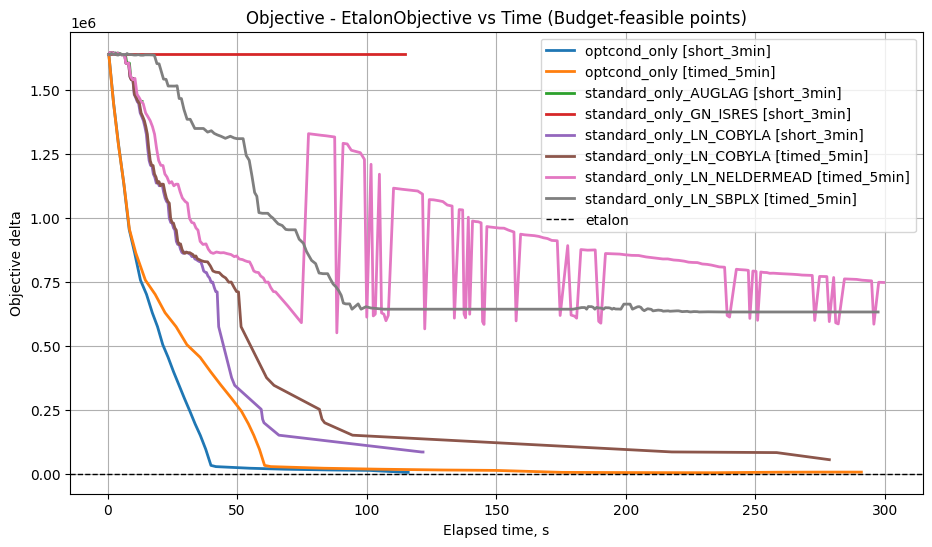

In [6]:
# Main metric: objective delta vs time (budget-feasible points only)
fig, ax = plt.subplots()
for series_label, group in trace_df.groupby('series_label'):
    g = group.sort_values('ElapsedTime(s)')
    ax.plot(g['ElapsedTime(s)'], g['objective_delta_to_etalon'], label=series_label, linewidth=2)

ax.axhline(0.0, color='black', linestyle='--', linewidth=1, label='etalon')
ax.set_title('Objective - EtalonObjective vs Time (Budget-feasible points)')
ax.set_xlabel('Elapsed time, s')
ax.set_ylabel('Objective delta')
ax.legend()
plt.show()


In [ ]:
# Objective value vs time (budget-feasible points only)
fig, ax = plt.subplots()
for series_label, group in trace_df.groupby('series_label'):
    g = group.sort_values('ElapsedTime(s)')
    ax.plot(g['ElapsedTime(s)'], g['Objective'], label=series_label, linewidth=2)

ax.set_title('Objective value vs Time (Budget-feasible points)')
ax.set_xlabel('Elapsed time, s')
ax.set_ylabel('Objective')
ax.legend()
plt.show()


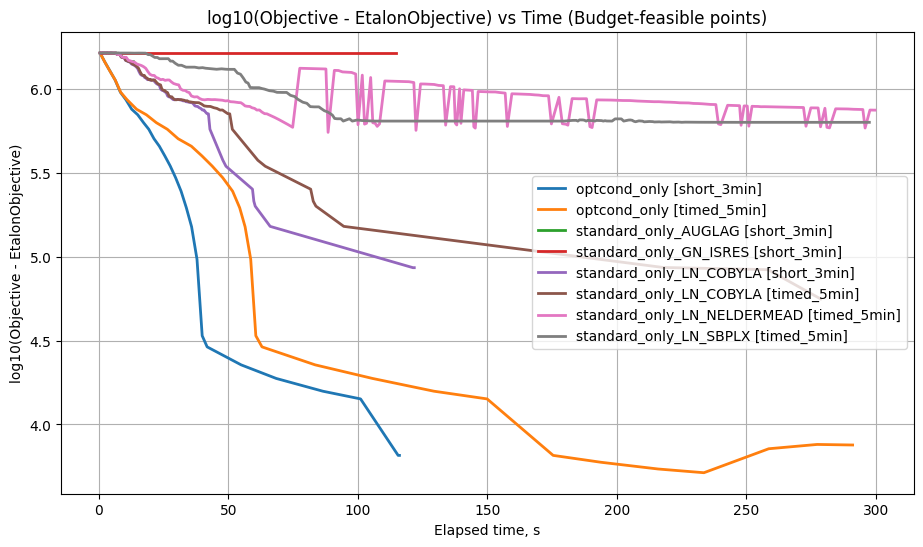

In [7]:
# log10(Objective - EtalonObjective) vs time (budget-feasible points only)
fig, ax = plt.subplots()
plotted = False

for series_label, group in trace_df.groupby('series_label'):
    g = group.sort_values('ElapsedTime(s)').copy()
    g['delta_pos'] = g['objective_delta_to_etalon'].where(g['objective_delta_to_etalon'] > 0)
    if g['delta_pos'].notna().any():
        ax.plot(g['ElapsedTime(s)'], np.log10(g['delta_pos']), label=series_label, linewidth=2)
        plotted = True

if not plotted:
    print('No positive objective deltas found: log10(Objective - Etalon) is undefined.')
else:
    ax.set_title('log10(Objective - EtalonObjective) vs Time (Budget-feasible points)')
    ax.set_xlabel('Elapsed time, s')
    ax.set_ylabel('log10(Objective - EtalonObjective)')
    ax.legend()
    plt.show()


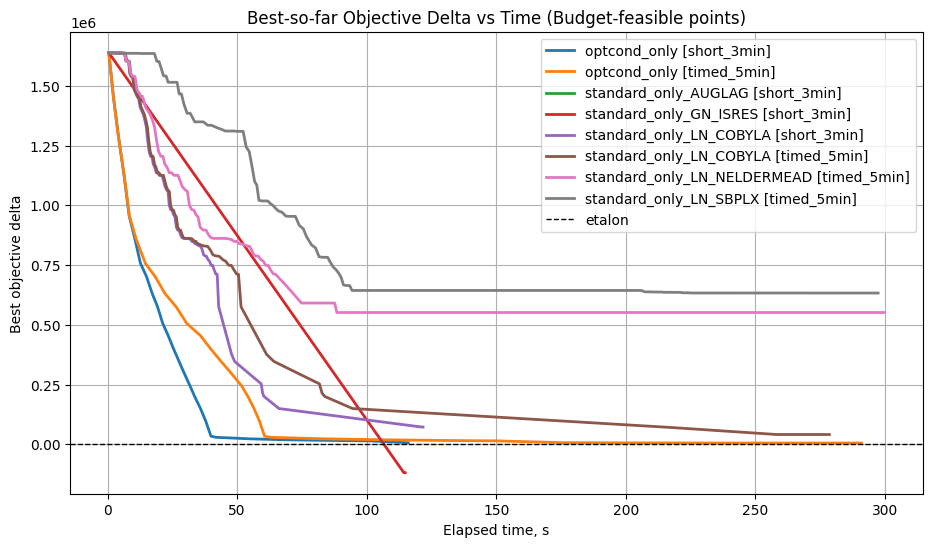

In [8]:
# Best-so-far objective delta vs time (budget-feasible points only)
fig, ax = plt.subplots()
for series_label, group in trace_df.groupby('series_label'):
    g = group.sort_values('ElapsedTime(s)')
    ax.plot(g['ElapsedTime(s)'], g['best_delta_so_far'], label=series_label, linewidth=2)

ax.axhline(0.0, color='black', linestyle='--', linewidth=1, label='etalon')
ax.set_title('Best-so-far Objective Delta vs Time (Budget-feasible points)')
ax.set_xlabel('Elapsed time, s')
ax.set_ylabel('Best objective delta')
ax.legend()
plt.show()


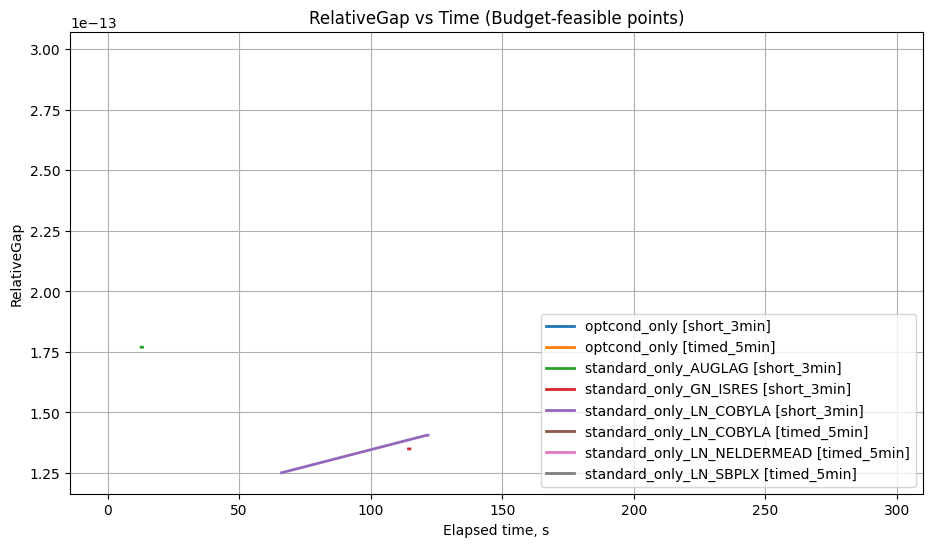

In [9]:
# Additional metric 1: RelativeGap vs time (budget-feasible points only)
fig, ax = plt.subplots()
for series_label, group in trace_df.groupby('series_label'):
    g = group.sort_values('ElapsedTime(s)')
    ax.plot(g['ElapsedTime(s)'], g['RelativeGap'], label=series_label, linewidth=2)

ax.set_title('RelativeGap vs Time (Budget-feasible points)')
ax.set_xlabel('Elapsed time, s')
ax.set_ylabel('RelativeGap')
ax.legend()
plt.show()


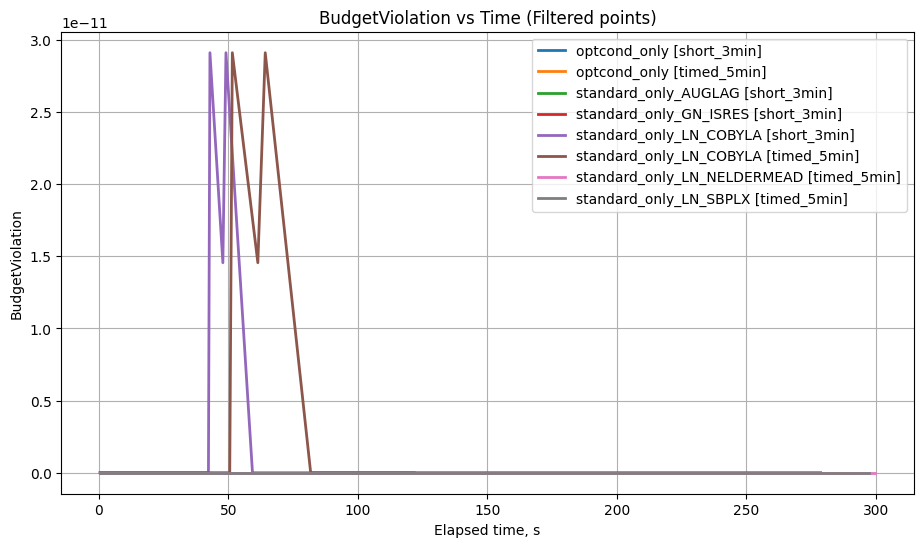

In [10]:
# Additional metric 2: BudgetViolation vs time (after filtering, should be ~0)
fig, ax = plt.subplots()
for series_label, group in trace_df.groupby('series_label'):
    g = group.sort_values('ElapsedTime(s)')
    ax.plot(g['ElapsedTime(s)'], g['BudgetViolation'], label=series_label, linewidth=2)

ax.set_title('BudgetViolation vs Time (Filtered points)')
ax.set_xlabel('Elapsed time, s')
ax.set_ylabel('BudgetViolation')
ax.legend()
plt.show()


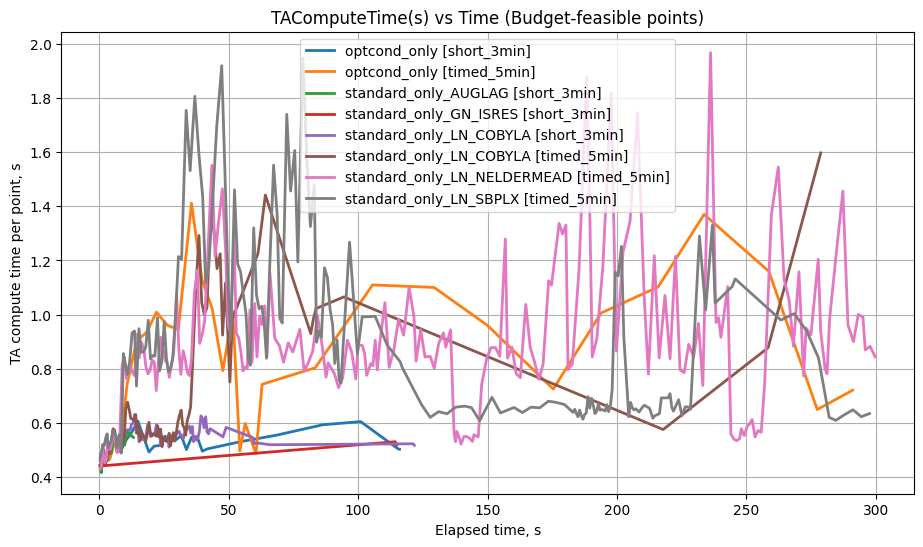

In [11]:
# Additional metric 3: TA compute time per trace point (budget-feasible points only)
fig, ax = plt.subplots()
for series_label, group in trace_df.groupby('series_label'):
    g = group.sort_values('ElapsedTime(s)')
    ax.plot(g['ElapsedTime(s)'], g['TAComputeTime(s)'], label=series_label, linewidth=2)

ax.set_title('TAComputeTime(s) vs Time (Budget-feasible points)')
ax.set_xlabel('Elapsed time, s')
ax.set_ylabel('TA compute time per point, s')
ax.legend()
plt.show()


In [12]:
# Final comparison table
final_table = comparison_df[[
    'run_group', 'scenario', 'run_id', 'status', 'elapsed_seconds',
    'objective', 'objective_for_ranking', 'delta_for_ranking',
    'total_travel_time', 'budget', 'algorithm',
    'max_standard_iterations', 'max_optimality_iterations'
]].sort_values('delta_for_ranking')
final_table


,run_group,scenario,run_id,status,elapsed_seconds,objective,objective_for_ranking,delta_for_ranking,total_travel_time,budget,algorithm,max_standard_iterations,max_optimality_iterations
4,timed_5min,optcond_only,sf_5min_optcond_20260226_132128,timeout_missing_summary,300.204,7.672993e+06,7670604.398,5157.191,7572992.913,100000.00000,LN_COBYLA,0,0
0,short_3min,optcond_only,sf_short_optcond_20260226_001601,success,154.768,7.671990e+06,7671989.877,6542.670,7571989.877,100000.00000,LN_COBYLA (Constrained Optimization BY Linear ...,0,25
5,timed_5min,standard_only_LN_COBYLA,sf_5min_std_cobyla_20260226_132128,timeout_missing_summary,300.134,7.708177e+06,7721502.523,56055.316,7606969.979,101207.18100,LN_COBYLA,0,0
1,short_3min,standard_only_LN_COBYLA,sf_short_std_cobyla_20260226_001601,success,161.514,7.751500e+06,7751499.829,86052.622,7651499.829,100000.00000,LN_COBYLA (Constrained Optimization BY Linear ...,220,0
6,timed_5min,standard_only_LN_NELDERMEAD,sf_5min_std_neldermead_20260226_132128,timeout_missing_summary,300.118,8.413509e+06,8216801.211,551354.004,8331960.696,81547.95409,LN_NELDERMEAD,0,0
7,timed_5min,standard_only_LN_SBPLX,sf_5min_std_sbplx_20260226_132128,timeout_missing_summary,300.088,4.545450e+07,8298290.045,632842.838,8193357.903,100609.59440,LN_SBPLX,0,0
3,short_3min,standard_only_AUGLAG,sf_short_std_auglag_20260226_001601,success,55.351,9.120428e+06,9120428.411,1454981.204,9106589.366,13839.04491,Custom Algorithm (36),220,0
2,short_3min,standard_only_GN_ISRES,sf_short_std_isres_20260226_001601,success,154.435,9.304167e+06,9304167.002,1638719.795,9304167.002,0.00000,GN_ISRES (Improved Stochastic Ranking Evolutio...,220,0
